In [ ]:
import pytbl
import busdates
import numpy as np
import pandas as pd
from functools import lru_cache
from rich.progress import track
import xarray as xr
from IPython.display import display, Markdown, Latex
from multiprocess import Pool
import tqdm
import matplotlib.pyplot as plt

In [14]:
major_ret = "ret900.1s"
rets = ['ret60.1s','ret300.1s','ret900.1s','ret1800.1s']
gid_selection = None

In [15]:
@lru_cache(maxsize=128)
def load_one_day(date):
    fn = f"/data/hdd/docker-dataspace/yuheng/rawdata/tick-dump/{date}.tbl"
    return pytbl.tbl_read(fn)

(df['src_epoch'] % (24 * 3600 ) +8*3600 )/3600

In [16]:
def work_one_day(date, feature_func):

    df = load_one_day(date).copy()
    if gid_selection is not None:
        df = df[df['gid'].isin(gid_selection)]
    alp_df = feature_func(df).fillna(0)
    alp_df['baseline'] = df['D-alpha']
    #calculate corr and FR
    stats_dict = {}
    for ret in rets:
        xy = alp_df.multiply(df[ret].values, axis='index').sum()
        xx = (alp_df**2).sum()
        yy = (df[ret]**2).sum()
        stats_dict[ret] = xr.Dataset({"xy": xy, "xx": xx, "yy": yy, "N": len(alp_df)}).to_array("stat").rename({"dim_0":"feature"})
    
    ret =  xr.Dataset(stats_dict).to_array("ret").expand_dims("date")
    ret.coords['date'] = [pd.to_datetime(date)]
    return ret

In [17]:
#corr = sum(x * y) / sqrt(sum(x*x) * sum(y*y))


In [18]:
def work_day_range(start_date, end_date, feature_func):
    dates = busdates.secDates("SHFE", start_date, end_date)
    pool = Pool(processes=16)
    def the_work(date):
        return work_one_day(date, feature_func)
    stats = list(tqdm.tqdm(pool.imap_unordered(the_work, dates), total=len(dates)))
    return xr.concat(stats, dim="date").sortby("date").to_dataset("stat")


In [19]:
# FR = xy / sqrt(xx) = corr * std(y)

In [36]:
def report_from_stat(stats):
    term_stats = stats.sel(feature = [x for x in stats.feature.values if x !="baseline"])
    corr = term_stats['xy'].sum("date") / np.sqrt(term_stats['xx'].sum("date") * term_stats['yy'].sum("date"))
    FR = term_stats['xy'].sum("date") / np.sqrt(term_stats['xx'].sum("date") * term_stats['N'].sum("date")) 
    FR_day = term_stats['xy'] / np.sqrt(term_stats['xx'] * term_stats['N'])

    #1. show corr and FR table
    display(Markdown("## correlation"))
    display(corr.to_dataset("feature").to_dataframe()*1e2)

    display(Markdown("## FR"))
    display(FR.to_dataset("feature").to_dataframe()*1e4)

    #2. FR cumsum plot on major_ret
    display(Markdown("## FR cumsum"))
    FR_day_sum = FR_day.sel(ret=major_ret).cumsum("date")
    for feature in FR_day_sum.feature:
        plt.plot(FR_day_sum.date, FR_day_sum.sel(feature=feature)*1e4 / len(FR_day_sum.date), label=feature.values)
    plt.legend()
    plt.show()
    plt.close()

In [32]:
def feature_0(df):
    df['mid'] = (df['AskPrice0'] + df['BidPrice0']) / 2
    df['hist_ret_1min'] = -df.groupby("gid")['mid'].diff(60 * 4).fillna(0) / df['mid']
    df['tot_ask'] = df['AskSize0'] + df['AskSize1'] + df['AskSize2'] + df['AskSize3'] + df['AskSize4']
    df['tot_bid'] = df['BidSize0'] + df['BidSize1'] + df['BidSize2'] + df['BidSize3'] + df['BidSize4']
    df['bar5'] = - (df['tot_ask'] - df['tot_bid']) / (df['tot_ask']+df['tot_bid'])
    df['bar'] = - (df['AskSize0'] - df['BidSize0']) / (df['AskSize0']+df['BidSize0'])
    return df[['hist_ret_1min', 'bar', 'bar5']]

In [33]:
stats_all = work_day_range("20220101", "20220801", feature_0)

100%|██████████| 139/139 [00:14<00:00,  9.62it/s]


## correlation

,hist_ret_1min,bar,bar5
ret,,,
ret60.1s,0.401986,0.522168,0.558426
ret300.1s,0.285786,0.183188,0.240715
ret900.1s,0.206612,0.071920,-0.163589
ret1800.1s,0.130480,-0.007727,-0.612487


## FR

,hist_ret_1min,bar,bar5
ret,,,
ret60.1s,0.046091,0.059870,0.064028
ret300.1s,0.066207,0.042438,0.055765
ret900.1s,0.078936,0.027477,-0.062499
ret1800.1s,0.069386,-0.004109,-0.325706


## FR cumsum

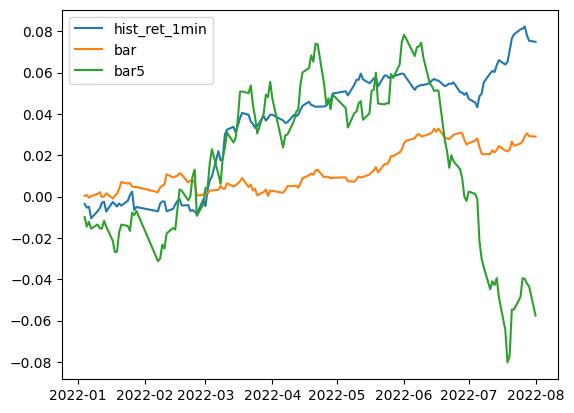

In [37]:
report_from_stat(stats_all)

# Universe

sid,symbol,type,ex,tick_size,lot_size,multiplier,name,sdate,edate,wgt.sh50,wgt.hs300,wgt.zz500,univ

900004,AU,FUTURE,SHFE,0.05,1000,0,沪金,0,0,,,,nonx

900009,CF,FUTURE,CZCE,5,5,0,郑棉,0,0,,,,nonx

900014,FG,FUTURE,CZCE,1,20,0,玻璃,0,0,,,,nonx

900023,JM,FUTURE,DCE,0.5,60,0,焦煤,0,0,,,,nonx

900027,M,FUTURE,DCE,1,10,0,豆粕,0,0,,,,nonx

900031,OI,FUTURE,CZCE,2,10,0,菜油,0,0,,,,nonx

900032,P,FUTURE,DCE,2,10,0,棕榈油,0,0,,,,nonx

900036,RB,FUTURE,SHFE,1,10,0,螺纹钢,0,0,,,,nonx

900041,RU,FUTURE,SHFE,5,10,0,橡胶,0,0,,,,nonx

900044,SN,FUTURE,SHFE,10,1,0,沪锡,0,0,,,,nonx

900045,SR,FUTURE,CZCE,1,10,0,白糖,0,0,,,,nonx

900059,AP,FUTURE,CZCE,1,10,1,苹果,0,0,,,,nonx